# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [23]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [24]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:00<00:00,  2.24it/s]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
0,NP_036255.2,NP_036255,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_036255.2,ENSG00000135297,ENSP00000419561,ENST00000498286
1,NP_066268.1,NP_066268,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_066268.1,ENSG00000087258,ENSP00000262493,ENST00000262493
2,UPI000012666A,UPI000012666A,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000012666A,ENSG00000169857,ENSP00000306822,ENST00000306730
3,NP_996991.1,NP_996991,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_996991.1,ENSG00000152092,ENSP00000395041,ENST00000424564
4,NP_001369746.2,NP_001369746,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001369746.2,ENSG00000135744,ENSP00000505985,ENST00000681269
...,...,...,...,...,...,...,...,...
4075,NP_000339.2,NP_000339,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_000339.2,ENSG00000277893,ENSP00000477587,ENST00000622030
4076,NP_002600.1,NP_002600,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_002600.1,ENSG00000113721,ENSP00000261799,ENST00000261799
4077,NP_003156.1,NP_003156,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003156.1,ENSG00000136854,ENSP00000362399,ENST00000373302
4078,NP_937799.1,NP_937799,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_937799.1,ENSG00000134086,ENSP00000344757,ENST00000345392


In [25]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins = er.map_ids(df=candidate_proteins,
                                input_col="RefSeq Protein")
candidate_proteins

Loading ==> /grid/koo/home/schilder/.cache/ensembl_rest/xref_external/8d12557b44866d35ec3d553ddce6afea.json.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,ENSG,ENST
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENSG00000160211,ENST00000393562
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401,ENSG00000010704,ENST00000357618
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483,ENSG00000001626,ENST00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225,ENSG00000012048,ENST00000357654
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050,ENSG00000139618,ENST00000380152
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121,ENSG00000198734,ENST00000367797
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509,ENSG00000244734,ENST00000335295
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000477615,NP_000286,ENSG00000277377,ENST00000620666
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518,ENSG00000130164,ENST00000558518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000488381,NP_000209,ENSG00000282076,ENST00000632153


### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [26]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=candidate_proteins["ENST"],
                              #  use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/11 [00:00<?, ?it/s]

`filter_prot_df` provides a convenient way to filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data,   
as well as which ones are present in the candidate proteins.

It will automatically figure out which `proteins_df` columns in it should be filtering on according to the prefixes in the `protein_ids` ('ENSP' or 'ENST' or 'protein') and `haplotypes` ('ENSP' or 'ENST').

It can also filter by the types of mutations you wish to inject during the VEP procedure (see the 'source_type' column for available options).

The final product is the filtered `proteins_df`, which we store as a new DataFrame `prot_df`.

In [27]:
prot_df = vp.filter_prot_df(proteins_df,
                            protein_ids=candidate_proteins["ENSP"],
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            )
prot_df

Filtering by 11 protein ids
Filtering by 1 source types
Filtering by ENST haplotypes
Returning 9 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
266,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295
760,NP_000286.3,NP_000286,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000286.3,ENSG00000277377,ENSP00000477615,ENST00000620666
1297,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084
1442,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654
2478,NP_000209.2,NP_000209,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000209.2,ENSG00000282076,ENSP00000488381,ENST00000632153
2906,NP_000393.4,NP_000393,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000393.4,ENSG00000160211,ENSP00000377192,ENST00000393562
3585,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSG00000130164,ENSP00000454071,ENST00000558518
3740,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618
3883,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186


We also need to remove any suspcious proteins that have a different reference sequence lengths in the Haplosaurus haplotypes and the ProteinGym mutations   
(which suggests that the ProteinGym proteins are not exactly the same as the Haplosaurus ones).

In [28]:
prot_df = vp.add_sequence_checks(prot_df,
                                  haplotypes=haplotypes)
prot_df = prot_df.loc[prot_df['proteingym_haplosaurus_seq_identical'] == True]
prot_df

Getting haplotype sequences:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST,proteingym_seq_len,haplosaurus_seq_len,proteingym_haplosaurus_seq_sim,proteingym_haplosaurus_seq_identical
266,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295,[147],[147],1.0,True
1297,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084,[1480],[1480],1.0,True
1442,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654,[1863],[1863],1.0,True
3585,NP_000518.1,NP_000518,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000518.1,ENSG00000130164,ENSP00000454071,ENST00000558518,[860],[860],1.0,True
3740,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618,[348],[348],1.0,True
3883,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186,[1159],[1159],1.0,True


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [39]:
vp.list_models()

['esm',
 'esm1_t12_85M_UR50S',
 'esm1_t34_670M_UR100',
 'esm1_t34_670M_UR50D',
 'esm1_t34_670M_UR50S',
 'esm1_t6_43M_UR50S',
 'esm1b_t33_650M_UR50S',
 'esm1v_t33_650M_UR90S',
 'esm1v_t33_650M_UR90S_1',
 'esm1v_t33_650M_UR90S_2',
 'esm1v_t33_650M_UR90S_3',
 'esm1v_t33_650M_UR90S_4',
 'esm1v_t33_650M_UR90S_5',
 'esm2_t12_35M_UR50D',
 'esm2_t30_150M_UR50D',
 'esm2_t33_650M_UR50D',
 'esm2_t36_3B_UR50D',
 'esm2_t48_15B_UR50D',
 'esm2_t6_8M_UR50D',
 'esm_if1_gvp4_t16_142M_UR50',
 'esm_msa1_t12_100M_UR50S',
 'esm_msa1b_t12_100M_UR50S',
 'esmfold_v0',
 'esmfold_v1']

Run VEP pipeline and store the results in `save_dir`.

In [4]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    save_dir = save_dir,
    models = ["esm1v_t33_650M_UR90S_1"],
    scoring_strategies = {"esm1v_t33_650M_UR90S_1":[
        "wt-marginals", 
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ]},
    run_filter_prot_df=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
    )
save_paths

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

In [35]:
vep_df = ESM.merge_vep(save_dir, 
                       add_metadata=True)
vep_df

Found 100 wt-marginals files


Reading files: 100%|██████████| 100/100 [00:00<00:00, 100.47it/s]


Found 99 masked-marginals files


Reading files: 100%|██████████| 99/99 [00:00<00:00, 104.28it/s]


Found 0 pseudo-ppl files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 23.95it/s]
/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3301: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-5.116528,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-8.493172,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,-9.365072,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.036350,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,ENSP00000454071:623I>V,NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,-4.447183,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81655,"ENSP00000350283:871P>L,1038E>G,1183K>R,1613S>G",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18R,MDLSALRVEEVQNVINARQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-0.907197,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA10602052,NaN,NaN,NaN,NaN,NaN,-4.274609,NaN,6,likely_path
81656,"ENSP00000350283:871P>L,1038E>G,1183K>R,1613S>G",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18T,MDLSALRVEEVQNVINATQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,0.165203,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA003550|UniProtKB:P38398#VAR_063899,NaN,NaN,NaN,NaN,NaN,-0.984293,NaN,6,path
81657,"ENSP00000350283:871P>L,1038E>G,1183K>R,1613S>G",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,M18K,MDLSALRVEEVQNVINAKQKILECPICLELIKEPVSTKCDHIFCKF...,Pathogenic,-0.205157,masked-marginals,False,esm2_t12_35M_UR50D,...,ClinGen:CA003549,NaN,NaN,NaN,NaN,NaN,-3.694999,NaN,6,likely_path
81658,"ENSP00000350283:871P>L,1038E>G,1183K>R,1613S>G",NP_009225.1,MDLSALRVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,R7L,MDLSALLVEEVQNVINAMQKILECPICLELIKEPVSTKCDHIFCKF...,Benign,0.714759,masked-marginals,False,esm2_t12_35M_UR50D,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.126186,NaN,5,likely_benign


In [36]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [37]:
seq_check_df, clinsig_counts, mutant_in_haplotype = ESM.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

,clinsig,mismatched_length,identical_sequences
0,benign,0,0
1,likely_benign,0,0
2,likely_path,0,0
3,path,0,0


,clinsig_count
likely_path,62257
likely_benign,8613
path,7901
benign,2889


,mutant_in_haplotype,clinsig,variant_count,variant_count_by_clinsig,variant_proportion,haplotype_count,haplotype_count_by_clinsig,haplotype_proportion
0,False,benign,142,156,0.910256,65,82,0.792683
1,False,likely_benign,239,242,0.987603,100,103,0.970874
2,False,likely_path,712,714,0.997199,81,83,0.975904
3,False,path,263,267,0.985019,100,105,0.952381
4,True,benign,14,156,0.089744,17,82,0.207317
5,True,likely_benign,3,242,0.012397,3,103,0.029126
6,True,likely_path,2,714,0.002801,2,83,0.024096
7,True,path,4,267,0.014981,5,105,0.047619


### Density plots (all proteins)

Filtered 3.3% of rows with NAs in col 'VEP'


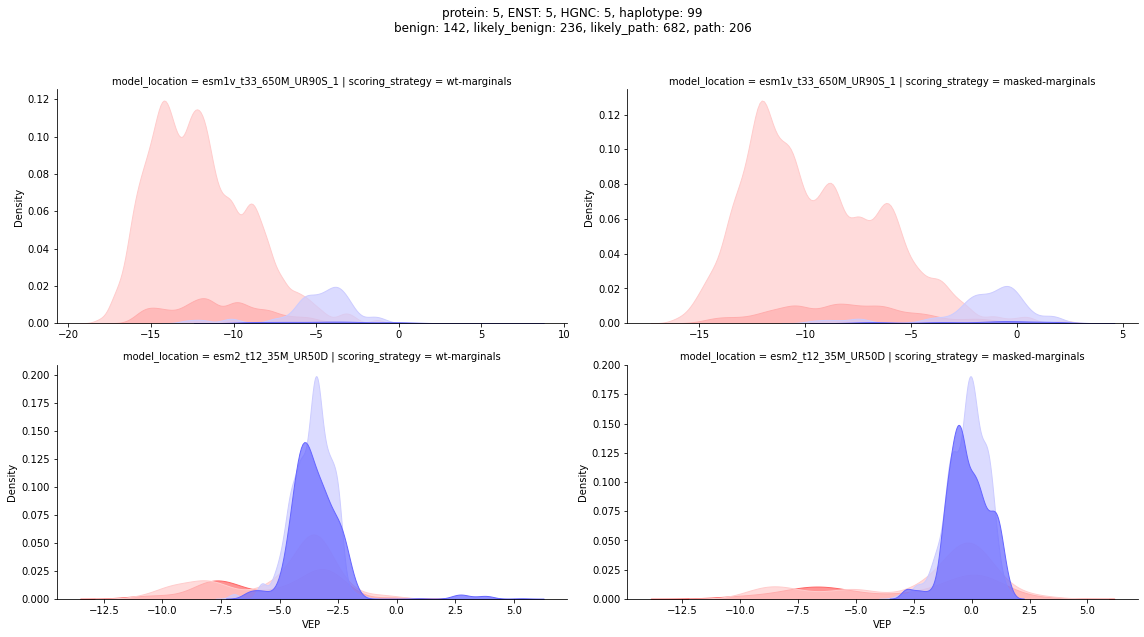

In [38]:
ESM.plot_vep_density(vep_df, 
                     multiple='layer')

Filtered 0.0% of rows with NAs in col 'esm1v_t33_650M_UR90S_1'


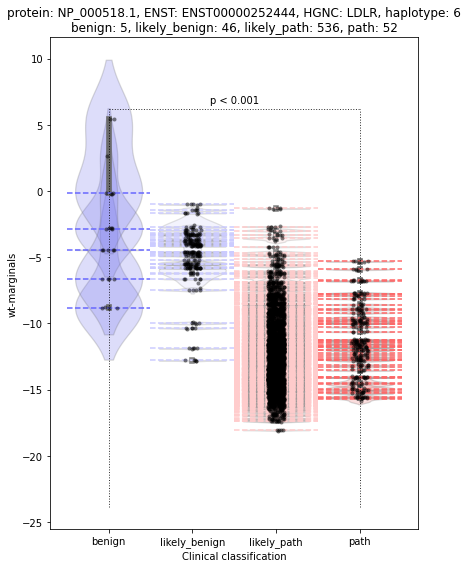

In [103]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="wt-marginals")

Filtered 0.0% of rows with NAs in col 'esm1v_t33_650M_UR90S_1'


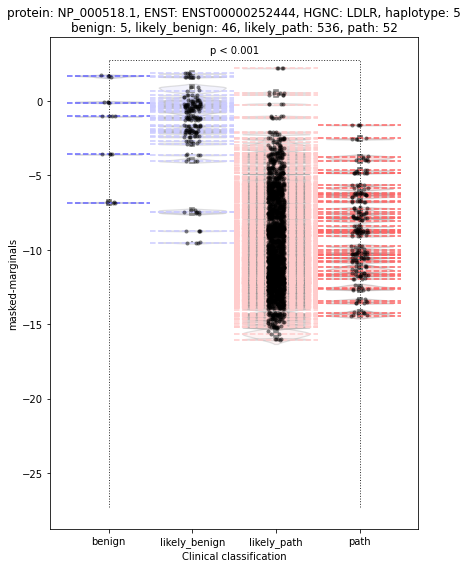

In [104]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="masked-marginals")